This notebook check the asymptotic of $\mathbb{E}[Y_n]$. The recurrence is

$$Y_{n+1} \stackrel{d}{=}  I^{(n)}\left(Y_{U_n}^{(1)} + Y_{n-1-U_n}^{(2)} + 1\right) + J^{(n)}\max\left(Y_{U_n}^{(1)}, Y_{n-1-U_n}^{(2)}\right), \quad Y_0=Y_1=0.$$

The variables $I$ and $J$ are Bernoulli with expectation $u$ and $v$ respectively such that $I^{(n)}+J^{(n)}\le 1$. The variable $U_n$ is uniform in $\{0,\ldots,n-1\}$. The superscripts are for iid copies. All the collections of iid copies are independent.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.metrics import r2_score
import seaborn as sns

#### Helpers

In [4]:
def report_memory(obj):
  try:
    bytes_alloc = obj.nbytes
  except Exception:
      import sys
      bytes_alloc = sys.getsizeof(obj)
  def _format_bytes(n):
      for unit in ['B','KB','MB','GB','TB']:
          if n < 1024.0:
              return f"{n:.2f}{unit}"
          n /= 1024.0
      return f"{n:.2f}PB"
  print(f"Allocated memory for 'history': {_format_bytes(bytes_alloc)} ({bytes_alloc} bytes)")

#### Monte-Carlo Simulation Helpers

In [8]:
def sample_from_empirical(X: np.ndarray, size=None) -> np.ndarray:
    """
    Sample with replacement from an empirical distribution defined by the array X. 
    
    Args:
      X (array-like): The empirical distribution to sample from.
      size (int, optional): The number of samples to draw. Defaults to the length of X.

    Returns:
      array-like: Samples from the empirical distribution.
    """
    if size is None:
        size = len(X)
    return np.random.choice(X, size=size, replace=True)

def plot_distribution(
        particle_array, 
        title="Empirical Distribution", 
        bins=100, clip_percentile=100, 
        log_y=False, show_bins=True, show_kde=False):
    """
    Plots the distribution of a 1D array of particles with optional bins and KDE.
    """
    clean_array = particle_array[np.isfinite(particle_array)]
    
    if clip_percentile < 100:
        max_val = np.percentile(clean_array, clip_percentile)
        view_array = clean_array[clean_array <= max_val]
        clip_note = f" (X-axis clipped at {clip_percentile}th percentile)"
    else:
        view_array = clean_array
        clip_note = ""

    plt.figure(figsize=(10, 6))
    
    if show_bins and show_kde:
        ax = sns.histplot(view_array, bins=bins, kde=True, 
                          stat="density", alpha=0.4)
                        
    elif show_bins and not show_kde:
        ax = sns.histplot(view_array, bins=bins, kde=False, 
                          stat="density", alpha=0.6)
                          
    elif not show_bins and show_kde:
        ax = sns.kdeplot(view_array, fill=True, alpha=0.3, linewidth=2, warn_singular=False)
        
    else:
        print("Error: Must choose to show either bins, KDE, or both.")
        return

    if log_y:
        ax.set_yscale('log')
        plt.ylabel("Density (Log Scale)")
    else:
        plt.ylabel("Density")
        
    plt.xlabel("Particle Value")
    plt.title(title + clip_note, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    emp_mean = np.mean(clean_array)
    plt.axvline(emp_mean, color='red', linestyle='dashed', linewidth=1, 
                label=f'Mean = {emp_mean:.4f}')
    
    plt.legend()
    plt.tight_layout()
    plt.show()

def wasserstein(X, Y, p=1):

    X = np.asarray(X)
    Y = np.asarray(Y)
    
    if len(X) != len(Y):
        raise ValueError(f"Distributions must have the same length. "
                         f"Got len(X)={len(X)} and len(Y)={len(Y)}.")
  
    X_sorted = np.sort(X)
    Y_sorted = np.sort(Y)
    distance = np.power(np.mean(np.abs(X_sorted - Y_sorted)**p), 1/p)
    
    return distance

#### Simulate $Y_n$

In [10]:
def simulate_Yn(u:float, v:float, N=1000, num_particles=1000):

    # Intialize the Yns. The first two arrays are already set to 0.
    history = np.zeros((N, num_particles), dtype=int)
    report_memory(history)
    
    
    for nplusone in range(2, N):
        n = nplusone - 1

        # Uniform indices
        Un = np.random.randint(0, n, size=num_particles)
        idx1 = Un
        idx2 = n - 1 - Un
        
        # Sample independent copies Y^(1) and Y^(2) 
        p_idx1 = np.random.randint(0, num_particles, size=num_particles)
        p_idx2 = np.random.randint(0, num_particles, size=num_particles)
        
        Y1 = history[idx1, p_idx1]
        Y2 = history[idx2, p_idx2]
        
        # Determine the Bernoulli events I and J
        rand_vals = np.random.rand(num_particles)
        
        mask_I = rand_vals < u
        mask_J = (rand_vals >= u) & (rand_vals < u + v)
        
        # Apply each particle to the corresponding branch
        Y_new = np.zeros(num_particles, dtype=int)
        Y_new[mask_I] = Y1[mask_I] + Y2[mask_I] + 1
        Y_new[mask_J] = np.maximum(Y1[mask_J], Y2[mask_J])
        
        history[n+1] = Y_new

        if (n+1) % 1000 == 0:
            print(f"Iteration {n+1}/{N} completed.")
    
    return history

#### Find "the" true $\alpha$

The algorithms to find $\alpha$ is based on the conjecture that there is a unique $\alpha$ such that the limiting distribution
$$X\stackrel{d}{=} I\left(X_{U_n}^{(1)} + X_{n-1-U_n}^{(2)}\right) + J\max\left(X_{U_n}^{(1)}, X_{n-1-U_n}^{(2)}\right)$$
admits a fixed point. Let
$$T_\alpha(X) = \mathcal{L}\left(I\left(X_{U_n}^{(1)} + X_{n-1-U_n}^{(2)}\right) + J\max\left(X_{U_n}^{(1)}, X_{n-1-U_n}^{(2)}\right)\right).$$

The intuition is that if $\alpha$ is too small, for every $X$, it is pushed to infinity. Otherwise, it is pushed to $0$.

In [6]:
def apply_T(X, u,v, alpha):
    # Sample independent pairs
    X1 = sample_from_empirical(X)
    X2 = sample_from_empirical(X)
    
    # Sample U, I and J
    U = np.random.uniform(0, 1, size=len(X))
    R = np.random.uniform(0, 1, size=len(X))
    
    I = (R < u).astype(np.float64)
    J = ((R >= u) & (R < u + v)).astype(np.float64)
    
    # Apply the operator T_alpha
    term1 = (U**alpha) * X1
    term2 = ((1 - U)**alpha) * X2
    
    T_X = I * (term1 + term2) + J * np.maximum(term1, term2)

    return T_X

The algorithm implements Robbins-Monro approximation. It adjusts $\alpha$ based on the mean of the last $T(X)$. If the mean is lower than $1$, it decreases $\alpha$, and otherwise. The learning rates $c_n$ are chosen such that $\sum c_n = \infty$ and $\sum c_n^2 < \infty$.

The intuition is that each application of $T$ change the *shape* of $X$ in the same way for an arbitrary $\alpha$.

In [7]:
def find_alpha_rm(u, v, initial_alpha, num_particles=100000, num_iters=20000, lrs=None, callback=None):
    """
    Use Robbins-Monro stochastic approximation.

    Args:
      u,v,initial_alpha (float): As specified in the problem.
      num_particles (int, optional): The number of particles to use in the empirical distribution.
      num_iters (int, optional): The number of iterations to run the Robbins-Monro algorithm.
      lrs (list, optional): The list of learning rates. Defaults to a sequence of learning rates defined by cₙ = c₀ / nᵞ where c₀ = 0.2 and γ = 0.65.
      callback (function, optional): A callback function that takes the current iteration number, the current empirical distribution, and the history of alpha values. This can be used for logging or visualization during the iterations.

    Returns:
      (alpha_history, X): A tuple containing the estimated optimal alpha value, samples from the empirical distribution at the final iteration, and the history of alpha values across iterations.

    """

    if lrs is None:
        c0 = 0.2
        gamma = 0.65 
        lrs = [c0 / (n ** gamma) for n in range(1, num_iters + 1)]
    
    if len(lrs) != num_iters:
        raise ValueError("Length of learning rates must match num_iters.")

    # Initialize the population as a Dirac delta at 1
    X = np.ones(num_particles)
    
    alpha = initial_alpha
    alpha_history = []

    for n in range(num_iters):
        
        # Apply T to the normalized X
        Y = apply_T(X, u, v, alpha)
        step_mean = np.mean(Y)
        X = Y / step_mean
        
        # If mean > 1, increase alpha, otherwise decrease it.
        alpha = alpha + lrs[n] * (step_mean - 1.0)
        if alpha <= 0:
            print(f"Warning: Alpha became non-positive at iteration {n+1}. Resetting 0.01.")
            alpha = 0.01
        
        alpha_history.append(alpha)

        if callback:
            callback(n, X, alpha_history)
    
    return alpha_history, X

In [2]:
def cummulative_mean(alpha, u, v, X, burn_in=15, num_iters=40):
    
    multipliers = []
    
    for i in range(burn_in + num_iters):
        Y = apply_T(X, u, v, alpha)
        step_mean = np.mean(Y)

        X = Y / step_mean
                
        # Record the multiplier (ignoring the burn-in period)
        if i >= burn_in:
            multipliers.append(step_mean)
            
    return np.mean(multipliers), X

def find_alpha_bisection(u=0.5, v=0.3, lower=None, upper=None, num_particles=100000, tolerance=1e-10, max_steps=15):
    """
    Uses bisection search to find the root of cummulative_mean(alpha) = 1.
    """
    print(f"Searching for alpha* for u={u}, v={v}")
    print(f"{'Step':<5} | {'Alpha Estimate':<20} | {'Cumulative Mean':<20}")
    print("-" * 40)

    if lower is None:
        lower = np.max([0, 2*u + v - 1])
    if upper is None:
        upper = np.min([1.0, 2*(u + v)])

    X_init = np.ones(num_particles)  # Start with a Dirac delta at 1
    
    for step in range(max_steps):
        mid_alpha = (lower + upper) / 2.0
        
        # Estimate the growth rate for this alpha
        current_mean, X = cummulative_mean(mid_alpha, u, v, X_init)
        
        print(f"{step+1:<5} | {mid_alpha:<20} | {current_mean:<20}")
        
        # Check for convergence
        if abs(current_mean - 1.0) < tolerance:
            print("-" * 40)
            print(f"Converged! alpha* = {mid_alpha:.5f}")
            return mid_alpha, X
            
        # If current_mean > 1, increase alpha.
        if current_mean > 1.0:
            lower = mid_alpha
        else:
            upper = mid_alpha
            
    print("-" * 40)
    print(f"Reached max steps. Best estimate for alpha* ≈ {mid_alpha}")
    return mid_alpha, X


#### Unit Test (can be skipped)

We need a clean way to save metadata.

In [9]:
def callback(iter, X, alpha_history, finished=False):
    if iter == 0:
        print(f"{'Iter':<6} | {'Current Alpha':<15} | {'Step Mean':<15} | {'P(X=0)' :<15}")
        print("-" * 60)
        return
    if iter % 2000 == 0:
        step_mean = np.mean(X)
        print(f"{iter:<6d} | {alpha_history[-1]:<15.5f} | {step_mean:<15.5f} | {1-np.count_nonzero(X)/len(X):<15.5f} ")

    if finished:
        # Polyak-Ruppert Averaging: Average the alpha values from the second half of the run
        burn_in = iter // 2
        averaged_alpha = np.mean(alpha_history[burn_in:])
        
        print("-" * 45)
        print(f"Polyak-Ruppert Estimate: {averaged_alpha:.5f}")

Searching for alpha* for u=0.5, v=0.3
Step  | Alpha Estimate       | Cumulative Mean     
----------------------------------------
1     | 0.65                 | 0.905783283410949   
2     | 0.47500000000000003  | 1.0011657358969592  
3     | 0.5625               | 0.950882302674071   
4     | 0.51875              | 0.975310661476309   
5     | 0.49687500000000007  | 0.988182813877984   
6     | 0.4859375            | 0.9943700222819848  
7     | 0.48046875           | 0.9978294858908964  
8     | 0.47773437500000004  | 0.9996913491193518  
9     | 0.47636718750000007  | 1.000265090448044   
10    | 0.47705078125000006  | 1.0000472927521618  
11    | 0.477392578125       | 0.9996593685144521  
12    | 0.47722167968750007  | 0.999914197207298   
13    | 0.4771362304687501   | 0.9997955749862367  
14    | 0.47709350585937504  | 0.9999992346515445  
15    | 0.4770721435546875   | 0.9999810254685719  
16    | 0.4770614624023438   | 0.9999628467721895  
17    | 0.47705612182617196  | 0.9998

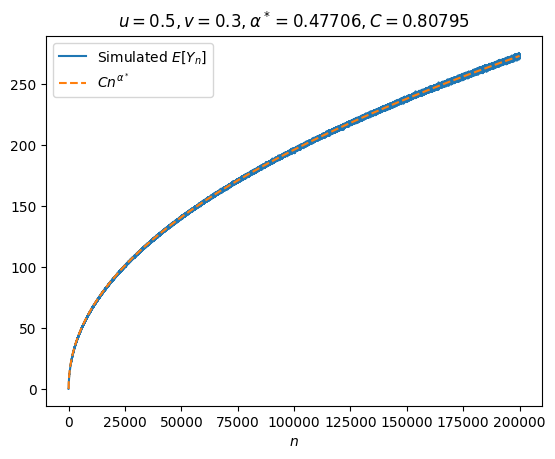

In [10]:
u=0.5
v=0.3
num_particles = 100000
N = 200000 


# Find alpha by bisection search

final_alpha, final_X = find_alpha_bisection(
  u=u, v=v,
  num_particles=1000000, tolerance=1e-20, max_steps=100
  )

# Find alpha by linear regression

Yns = simulate_Yn(u, v, N, num_particles)
EYns = np.mean(Yns, axis=1)

start_idx = int(N * 0.1)
tail_idx = int(N * 0.8)

log_n = np.log(np.arange(start_idx, N))
log_Y = np.log(EYns[start_idx:N])
slope, intercept, r_value, p_value, std_err = linregress(log_n, log_Y)
alpha_error = np.abs(slope - final_alpha)

print(f"Final alpha: {final_alpha}, Slope: {slope}, Alpha Error: {alpha_error}")

# Plot

C = EYns[-1]/(N-1)**final_alpha
theoretical_Yn = C * np.arange(0, N)**final_alpha

plt.plot(EYns, label='Simulated $E[Y_n]$')
plt.plot(np.arange(0, N), theoretical_Yn, 
         label='$Cn^{\\alpha^*}$', linestyle='dashed')
plt.xlabel('$n$')
plt.title(f'$u={u}, v={v}, \\alpha^*={final_alpha:.5f}, C={C:.5f}$')
plt.legend()
plt.show()

Searching for alpha* for u=0.4, v=0.15
Step  | Alpha Estimate       | Cumulative Mean     
----------------------------------------
1     | 0.5                  | 0.7278248726236001  
2     | 0.25                 | 0.8695241275974025  
3     | 0.125                | 0.9643210634775073  
4     | 0.0625               | 1.0203887142301764  
5     | 0.09375              | 0.991066529502626   
6     | 0.078125             | 1.0053143404087552  
7     | 0.0859375            | 0.9986521903950628  
8     | 0.08203125           | 1.0019238534496853  
9     | 0.083984375          | 1.0005540760876612  
10    | 0.0849609375         | 0.9995413019348481  
11    | 0.08447265625        | 1.0007637060143857  
12    | 0.084716796875       | 0.9998853491999034  
13    | 0.0845947265625      | 0.9992986842304686  
14    | 0.08453369140625     | 0.9994480481766341  
15    | 0.084503173828125    | 0.9995880232469844  
16    | 0.0844879150390625   | 0.9989161202610392  
17    | 0.08448028564453125  | 1.000

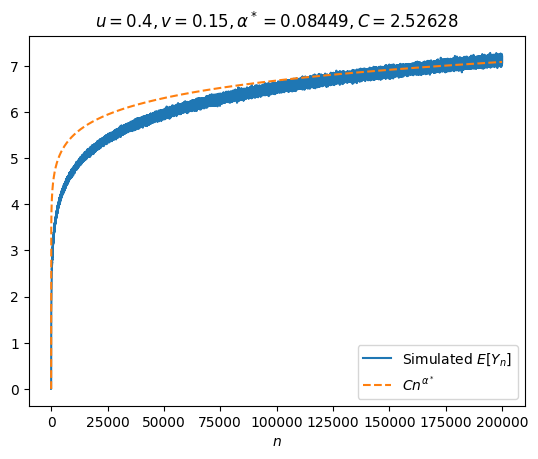

In [11]:
u=0.4
v=0.15
num_particles = 100000
N = 200000 


# Find alpha by bisection search

final_alpha, final_X = find_alpha_bisection(
  u=u, v=v,
  num_particles=1000000, tolerance=1e-20, max_steps=50
  )

# Find alpha by linear regression

Yns = simulate_Yn(u, v, N, num_particles)
EYns = np.mean(Yns, axis=1)

start_idx = int(N * 0.1)
tail_idx = int(N * 0.8)

log_n = np.log(np.arange(start_idx, N))
log_Y = np.log(EYns[start_idx:N])
slope, intercept, r_value, p_value, std_err = linregress(log_n, log_Y)
alpha_error = np.abs(slope - final_alpha)

print(f"Final alpha: {final_alpha}, Slope: {slope}, Alpha Error: {alpha_error}")

# Plot

C = EYns[-1]/(N-1)**final_alpha
theoretical_Yn = C * np.arange(0, N)**final_alpha

plt.plot(EYns, label='Simulated $E[Y_n]$')
plt.plot(np.arange(0, N), theoretical_Yn, 
         label='$Cn^{\\alpha^*}$', linestyle='dashed')
plt.xlabel('$n$')
plt.title(f'$u={u}, v={v}, \\alpha^*={final_alpha:.5f}, C={C:.5f}$')
plt.legend()
plt.show()

#### Check agreement on a grid of $(u,v)$

We need to run the experiment over many cases of $(u,v)$, intended to last less than 24 hours. To do that, we have to run more unit tests to see the tradeoff between precision and runtime. We also have to choose a proper metric that can compare how good the returned $\alpha^*$ is across the cases. Note that average error does not work, since it is not scale-invariant.

In [ ]:
num_particles = 100000
num_iters = 20000

def check_asymptotic(u, v):
    initial_alpha = 2*u+v-1.0
    alpha_history, X = find_alpha_rm(u, v, initial_alpha, num_particles, num_iters, None, None)
    